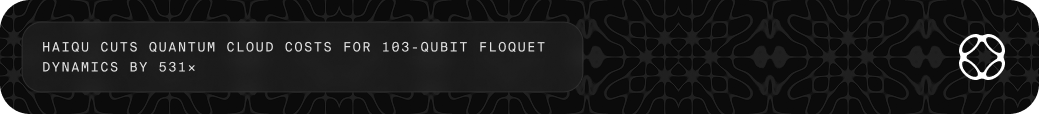

We simulate the dynamics of a **103-qubit kicked Ising (Floquet) model** on a real IBM Heron processor and compare Haiqu's orchestration engine against a baseline PEC-based error-mitigation pipeline. Both reach the same magnetisation curve, but Haiqu does it in **~42 seconds** at **~$34** versus the baseline **~3.1 hours** at **~$17,856** (531× faster, 531× cheaper). Original benchmark: [, *arXiv* 2508.10997 (2025)](https://arxiv.org/abs/2508.10997).

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

## Initialize the notebook

Import the necessary libraries, set the run mode and credentials, initialise the Haiqu SDK, load the device, and show the connectivity map.

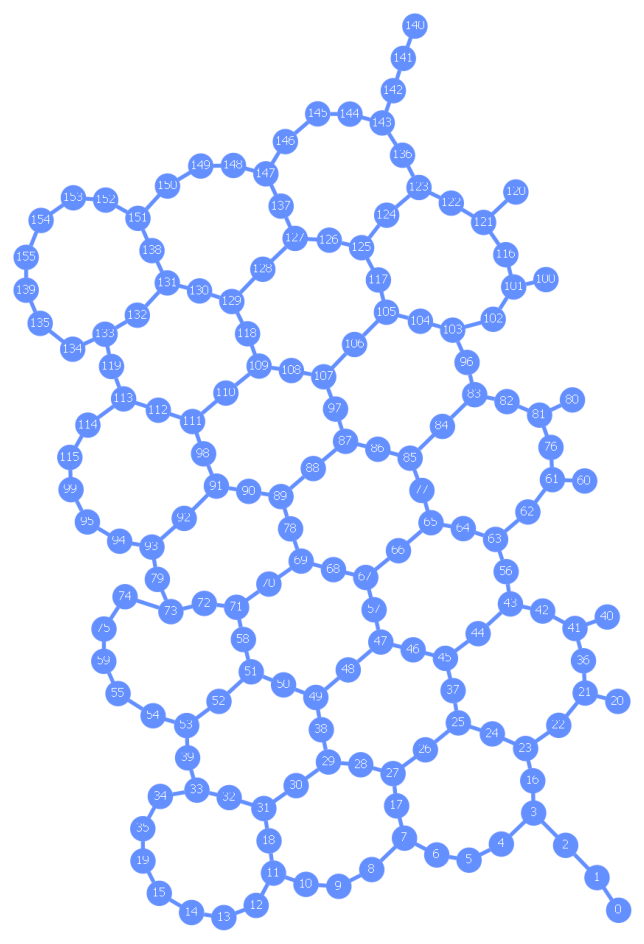

In [1]:
import json
from qiskit.quantum_info import SparsePauliOp
from haiqu.sdk import haiqu
from utils.kicked_ising_utils import (
    make_kicked_ising_circuit, load_json_data,
    plot_magnetization, plot_performance, plot_pareto, show_device_connectivity,
)

# ── Configuration ───────────────────────────────────────────
RUN_ON_DEVICE = False        # set True to actually submit and retrieve
DEVICE_ID = "ibm_kingston"   # or "fake_marrakesh" for a free local simulator
OPTIONS = {                  # set to {} when using a fake device
    "ibm_quantum_token":    "YOUR_IBM_QUANTUM_TOKEN",
    "ibm_quantum_instance": "YOUR_IBM_QUANTUM_INSTANCE",
}
N_QUBITS = 103

haiqu.login()
haiqu.init("Kicked Ising Simulation")

device = haiqu.get_device(DEVICE_ID)
show_device_connectivity(coupling_map=device.coupling_map, figsize=(12, 12))

## The model

The kicked Ising Hamiltonian is a Floquet (periodically driven) system with three non-commuting terms:

$$H = \theta_{ZZ} \sum_{\langle i,j \rangle} Z_i Z_j \;+\; \theta_X \sum_i X_i \;+\; \theta_Z \sum_i Z_i$$

Each Floquet step applies them stroboscopically: $U(n) = (e^{-iH_Z} e^{-iH_X} e^{-iH_{ZZ}})^n$ for $n$ steps. Sweeping $n$, we measure the average magnetisation $M = \tfrac{1}{N}\sum_i \langle Z_i \rangle$.

> 💡 **Note on classical intractability:** The standard 2D transverse-field Ising model from the IBM Nature paper (Kim et al., 2023) uses a two-term Hamiltonian $H = -J \sum_{\langle i,j \rangle} Z_i Z_j + h \sum_i X_i$. The kicked Ising model in this notebook is from the (baseline paper) (https://arxiv.org/abs/2508.10997) and uses a three-term Floquet Hamiltonian with parameters $\alpha_{ZZ} = 1.0$, $\alpha_X = 1.6$, $\alpha_Z = 0.3$, deliberately chosen far from any integrable point. The extra longitudinal field term ($\alpha_Z \sum_i Z_i$) breaks integrability, the large non-commuting gate angles drive rapid entanglement growth that breaks MPS/TN methods, and the far-from-Clifford parameters defeat Pauli propagation approaches. This is a fundamentally harder problem to simulate classically.

In [2]:
# Floquet evolution circuits: one per number of Floquet steps
NUM_STEPS_LIST = [5, 6, 7, 8, 9]
SHOTS = 8192
THETA_ZZ, THETA_X, THETA_Z = 1.0, 1.6, 0.3

circuits = [
    make_kicked_ising_circuit(
        num_qubits=N_QUBITS, num_steps=num_steps,
        backend_coupling_map=device.coupling_map,
        theta_zz=THETA_ZZ, theta_x=THETA_X, theta_z=THETA_Z,
    )
    for num_steps in NUM_STEPS_LIST
]

# Observable: average single-site Z magnetisation, M = (1/N) sum_i <Z_i>
paulis = ["I" * i + "Z" + "I" * (N_QUBITS - i - 1) for i in range(N_QUBITS)]
magnetisation = SparsePauliOp(paulis, [1 / N_QUBITS] * N_QUBITS)
print(f"Built {len(circuits)} circuits ({N_QUBITS} qubits, Floquet steps {NUM_STEPS_LIST})")

Built 5 circuits (103 qubits, Floquet steps [5, 6, 7, 8, 9])


## Submit jobs to the QPU

We submit one circuit per Floquet step count, twice over: once without error mitigation (**Noisy**) and once with Haiqu's mitigation engine (**Haiqu**). The job IDs are saved to disk so we can pick up the results later in a new session: QPU jobs can take minutes to hours to complete. Set `RUN_ON_DEVICE = True` to execute on real hardware (requires IBM Quantum credentials); otherwise the notebook will load cached results from a previous run further down.

In [3]:
JOB_IDS_FILE = "saved_job_ids.json"
LOAD_FROM_JOB = False  # set this to True if you wish to load results by fetching them from already executed jobs.

if RUN_ON_DEVICE:
    saved_job_ids = {"noisy": [], "haiqu": []}
    for circuit in circuits:
        job = haiqu.run(
            circuit, observables=[magnetisation],
            shots=SHOTS, device_id=DEVICE_ID, options=OPTIONS,
        )
        saved_job_ids["noisy"].append(job.id)
    for circuit in circuits:
        job = haiqu.run(
            circuit, observables=[magnetisation],
            shots=SHOTS, device_id=DEVICE_ID, options=OPTIONS, use_mitigation=True,
        )
        saved_job_ids["haiqu"].append(job.id)
    with open(JOB_IDS_FILE, "w") as f:
        json.dump(saved_job_ids, f)
    print(f"Submitted {len(saved_job_ids['noisy'])} noisy + {len(saved_job_ids['haiqu'])} Haiqu jobs")
    print(f"Job IDs saved to {JOB_IDS_FILE}")
else:
    print("Skipping live submission: cached results will be loaded next.")

Skipping live submission: cached results will be loaded next.


## Retrieve results

For live runs, we load the saved job IDs and call `haiqu.get_job(job_id).result()` for each. This works in a fresh notebook session too, so you can submit, walk away while the QPU runs, then come back later to retrieve. For the cached path we read JSON files from a previous run. Either way we end up with the same four magnetisation curves over Floquet steps: **Ideal** (noise-free simulation), **Noisy** (raw QPU), **Baseline** (PEC), **Haiqu** (ours): plus runtime and cost for the two we submitted.

In [4]:
if RUN_ON_DEVICE or LOAD_FROM_JOB:
    with open(JOB_IDS_FILE) as f:
        saved_job_ids = json.load(f)
    noisy_mag, noisy_sec, noisy_usd = [], 0.0, 0.0
    for jid in saved_job_ids["noisy"]:
        job = haiqu.get_job(jid)
        noisy_mag.append(job.result()[0][0])
        noisy_sec += job.qpu_cost["native"]["amount"]
        noisy_usd += job.qpu_cost["converted"]["amount"]
    haiqu_mag, haiqu_sec, haiqu_usd = [], 0.0, 0.0
    for jid in saved_job_ids["haiqu"]:
        job = haiqu.get_job(jid)
        haiqu_mag.append(job.result()[0][0])
        haiqu_sec += job.qpu_cost["native"]["amount"]
        haiqu_usd += job.qpu_cost["converted"]["amount"]
    noisy_min, haiqu_min = noisy_sec / 60, haiqu_sec / 60
else:
    noisy_blob = load_json_data("cache/noisy.json")
    haiqu_blob = load_json_data("cache/haiqu.json")
    noisy_mag, haiqu_mag = noisy_blob["results"][0][0], haiqu_blob["results"][0][0]
    noisy_min = noisy_blob["qpu_cost"]["native"]["amount"] / 60
    noisy_usd = noisy_blob["qpu_cost"]["converted"]["amount"]
    haiqu_min = haiqu_blob["qpu_cost"]["native"]["amount"] / 60
    haiqu_usd = haiqu_blob["qpu_cost"]["converted"]["amount"]

# Reference curves: noise-free simulation and Baseline published result (2025)
ideal      = load_json_data("cache/ideal.json")[0][0]
baseline = load_json_data("cache/baseline.json")[0][0]
baseline_min, baseline_usd = 3.1 * 60, 17856  # 3.1 hours, baseline paper

> 💡 **Good to Know:** The magnetisation oscillates with Floquet steps as the system evolves under periodic driving. The solution obtained with Haiqu closely matches the one obtained in the Baseline. Both improve quality versus the noisy benchmark.

"Logged object to the experiment 'Kicked Ising Simulation'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

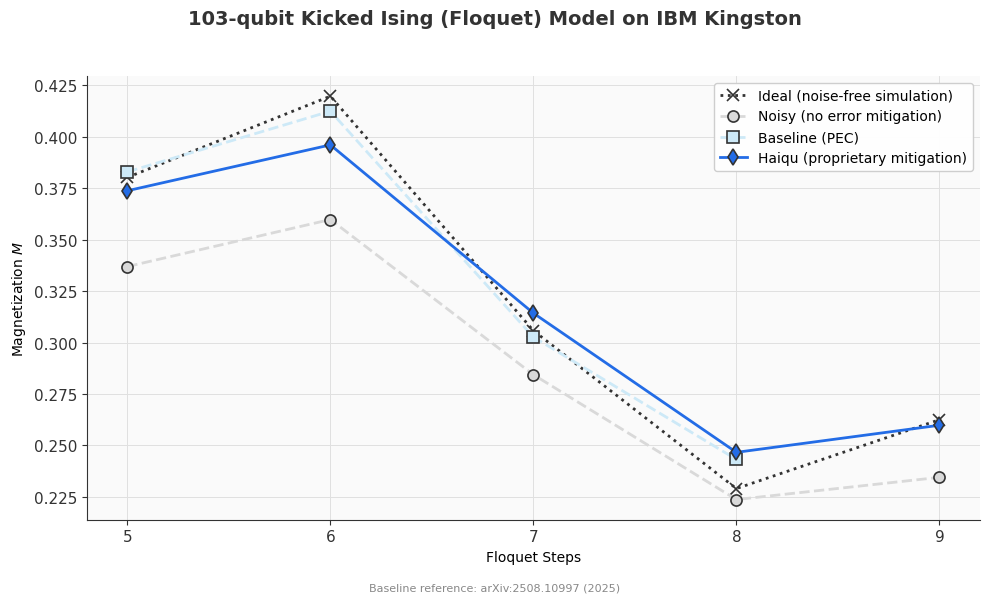

In [5]:
haiqu.log(
    plot_magnetization(
        num_steps_list=NUM_STEPS_LIST,
        ideal_mag=ideal,
        noisy_mag=noisy_mag,
        baseline_mag=baseline,
        haiqu_mag=haiqu_mag,
    ),
    name="magnetisation",
)

> 💡 **Good to Know:** Haiqu's algorithmic and orchestration engine reduces the time to solution from 3.1h to ~42s and the cost of solution from ~$17,856 to ~$34 compared to the Baseline implementation. The Baseline PEC overhead grows multiplicatively with gate count: at 972 gates, scaling to comparable accuracy would push their costs to hundreds of thousands of dollars per circuit. Haiqu achieves comparable accuracy at these scales for less than a hundred dollars per circuit.

"Logged object to the experiment 'Kicked Ising Simulation'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

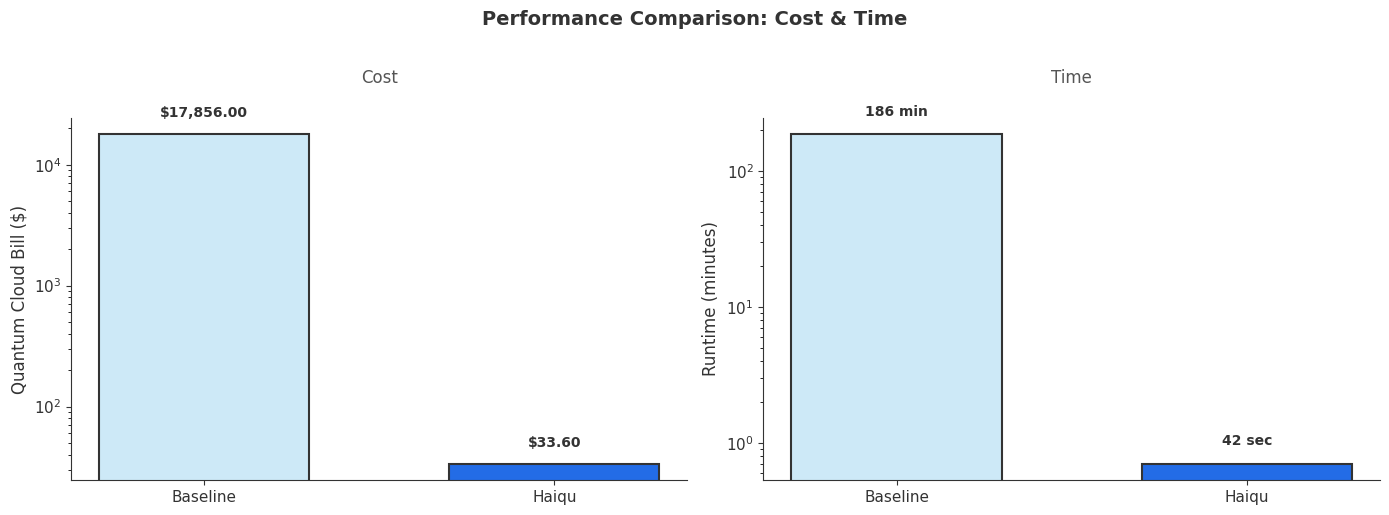

In [6]:
haiqu.log(
    plot_performance(
        labels=["Baseline", "Haiqu"],
        costs=[baseline_usd, haiqu_usd],
        times=[baseline_min, haiqu_min],
    ),
    name="performance",
)

"Logged object to the experiment 'Kicked Ising Simulation'. You can see logged data on Dashboard: https://dashboard.haiqu.ai"

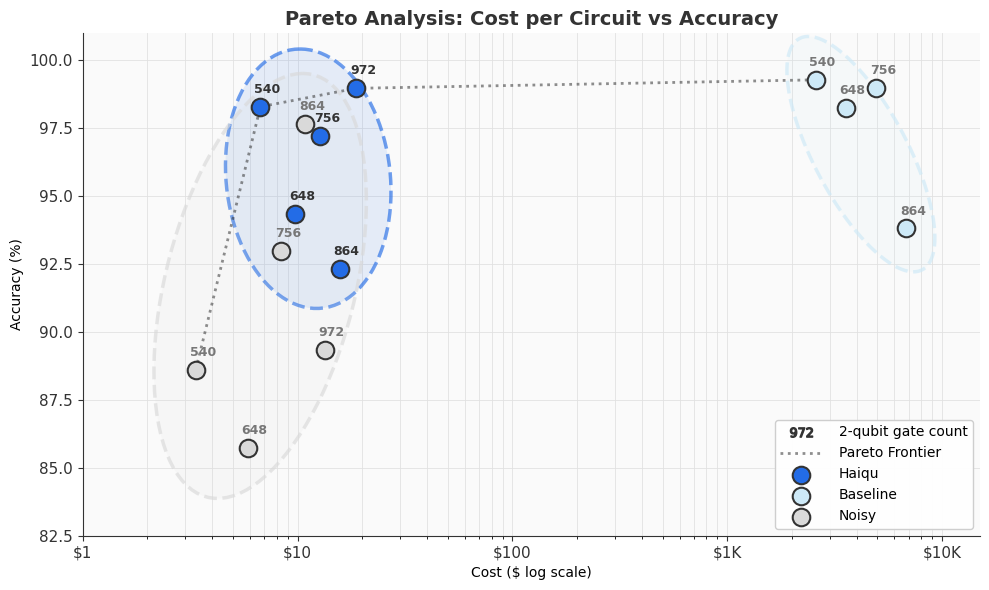

In [7]:
haiqu.log(
    plot_pareto(
        num_steps_list=NUM_STEPS_LIST,
        ideal_mag=ideal,
        haiqu_mag=haiqu_mag,
        haiqu_bill=haiqu_usd,
        baseline_mag=baseline,
        baseline_bill=baseline_usd,
        noisy_mag=noisy_mag,
        noisy_bill=noisy_usd,
    ),
    name="pareto",
)

## Conclusion

This notebook benchmarked Haiqu's orchestration engine against a Baseline PEC-based error mitigation pipeline on a **103-qubit kicked Ising (Floquet) model**: a utility-scale quantum dynamics simulation that exceeds the reach of brute-force classical methods.

**Key findings:**

| Metric | Baseline | Haiqu | Improvement |
|---|---|---|---|
| Quantum processor runtime | ~3.1 hours | ~42 seconds | **531x faster** |
| Quantum cloud bill | ~\$17,856 | ~\$34 | **531x cheaper** |
| Accuracy | Close to ideal | Close to ideal | Equivalent |

Haiqu achieves equivalent accuracy to the Baseline PEC pipeline at **531x lower cost and time**, enabled by proprietary lightweight error mitigation and intelligent circuit orchestration. The Pareto plot above confirms that Haiqu occupies the optimal trade-off point: high quality at minimal cost.

**Why is this model harder than the standard Ising model?** The kicked Ising model from the [Baseline paper](https://arxiv.org/abs/2508.10997) uses a three-term Floquet Hamiltonian with parameters $\theta_{ZZ} = 1.0$, $\theta_X = 1.6$, $\theta_Z = 0.3$, deliberately chosen far from any integrable point. The extra longitudinal field term breaks integrability, the large non-commuting gate angles drive rapid entanglement growth that breaks MPS/TN methods, and the far-from-Clifford parameters defeat Pauli propagation approaches.

**Reference:** "Scalable quantum error mitigation of mid-circuit measurements," *arXiv* 2508.10997 (2025). [arxiv.org/abs/2508.10997](https://arxiv.org/abs/2508.10997)

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

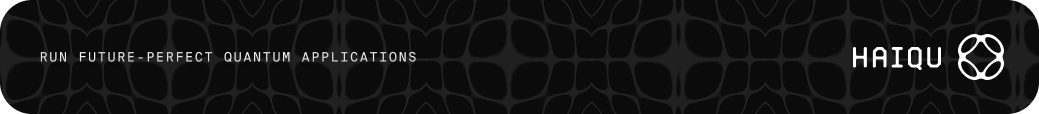